# 4. The 51k studio-photo dataset

Before the combined dataset there was a much bigger dataset: 51,161 photos of fresh and rotten apples, bananas, grapes, mangoes and oranges, one fruit per photo on a plain background, split 80/10/10. The photos came from an image-classification set, so the boxes were generated automatically (`Sam.ipynb`). This notebook covers two problems found in it, the model trained after fixing them, and why that model isn't the one in the demo.

The downloaded dataset is only read here. The corrected copy is written to `datasets/studio-6class/` by `prepare_data.py`.

In [1]:
import os
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path[:0] = [os.getcwd(), "notebooks"]

import hashlib
import json
import random
import subprocess

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from ultralytics import YOLO

import viz
from dataset_stats import box_ok, count_split, dhash, list_images, load_dataset
from prepare_data import fix_box

viz.setup()
SRC = Path("datasets/studio")
splits, names = load_dataset(SRC)
images = {s: list_images(p) for s, p in splits.items()}

rows = []
for split, files in images.items():
    for img in files:
        for line in (img.parent.parent / "labels" / f"{img.stem}.txt").read_text().splitlines():
            c, *box = line.split()
            rows.append((split, img, names[int(c)], *map(float, box)))
labels = pd.DataFrame(rows, columns=["split", "image", "cls", "xc", "yc", "w", "h"])
print(f"{len(labels):,} boxes on {sum(map(len, images.values())):,} photos")

51,161 boxes on 51,161 photos


In [2]:
counts = labels.pivot_table(index="cls", columns="split", values="image", aggfunc="count")
counts = counts.loc[list(names.values()), ["train", "val", "test"]]
counts.loc["total"] = counts.sum()
counts

split,train,val,test
cls,,,
fresh_apple,4931,583,606
rotten_apple,304,38,35
fresh_banana,4793,614,585
rotten_banana,4051,505,500
fresh_grape,4889,612,659
rotten_grape,4027,515,498
fresh_mango,4885,604,615
rotten_mango,4049,506,485
fresh_orange,4793,621,610


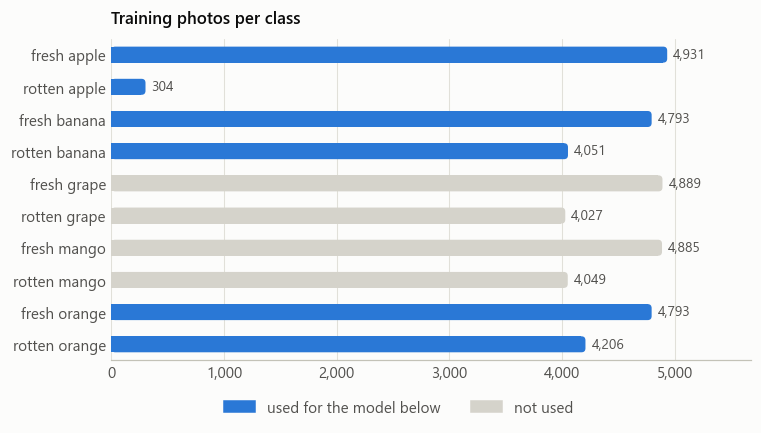

In [3]:
train = counts["train"].drop("total")
colors = [viz.BLUE if n.split("_")[1] in ("apple", "banana", "orange") else viz.CONTEXT for n in train.index]
fig, ax = plt.subplots(figsize=(7.5, 3.8))
viz.hbars(ax, [n.replace("_", " ") for n in train.index], train.to_numpy(), colors)
ax.set_title("Training photos per class")
ax.legend(handles=[Patch(color=viz.BLUE, label="used for the model below"), Patch(color=viz.CONTEXT, label="not used")],
          loc="upper center", bbox_to_anchor=(0.45, -0.08), ncol=2)
viz.render(fig)

## Problem 1: every box was wrong

`Sam.ipynb` made one box per photo: mask out the low-saturation background in HSV, take the largest contour and use its bounding rectangle. One line in it was wrong:

```python
xmin, ymin, xmax, ymax = cv2.boundingRect(contours)   # boundingRect returns x, y, width, height
```

Here is the same code, with the original unpacking behind a flag:

In [4]:
def hsv_box(path, original_bug=False):
    """Box around the fruit as normalised YOLO (xc, yc, w, h). Adapted from Sam.ipynb."""
    img = cv2.imread(str(path))
    mask = cv2.inRange(cv2.cvtColor(img, cv2.COLOR_BGR2HSV), (0, 0, 0), (255, 50, 255))  # low saturation = background
    mask = cv2.bitwise_not(cv2.threshold(cv2.blur(mask, (2, 2)), 0, 255, cv2.THRESH_BINARY)[1])
    contours, _ = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
    H, W = mask.shape
    if original_bug:
        xmin, ymin, xmax, ymax = x, y, w, h
        return (xmin + (xmax - xmin) / 2) / W, (ymin + (ymax - ymin) / 2) / H, (xmax - xmin) / W, (ymax - ymin) / H
    return (x + w / 2) / W, (y + h / 2) / H, w / W, h / H


random.seed(0)
sample = random.sample(range(len(labels)), 500)
same = sum(np.allclose(hsv_box(labels.image[i], original_bug=True), labels.loc[i, ["xc", "yc", "w", "h"]].to_numpy(float))
           for i in sample)
print(f"the original code reproduces the stored box exactly for {same} of {len(sample)} random photos")

the original code reproduces the stored box exactly for 500 of 500 random photos


So every stored box has the right top-left corner, but its right and bottom edges land at the fruit's width and height instead of at `x + width` and `y + height`. Boxes come out shifted, and whenever a fruit starts further from the edge than it is wide, the width goes negative. YOLO drops those photos as corrupt.

In [5]:
stored = labels[["xc", "yc", "w", "h"]].to_numpy()
fixed = np.array([fix_box(*b) for b in stored])


def iou(a, b):
    """IoU of normalised YOLO boxes, row by row. Boxes with a negative size count as empty."""
    a1, a2 = a[:, :2] - a[:, 2:] / 2, a[:, :2] + a[:, 2:] / 2
    b1, b2 = b[:, :2] - b[:, 2:] / 2, b[:, :2] + b[:, 2:] / 2
    inter = np.clip(np.minimum(a2, b2) - np.maximum(a1, b1), 0, None).prod(1)
    return inter / (np.clip(a[:, 2:], 0, None).prod(1) + b[:, 2:].prod(1) - inter)


labels["invalid"] = [not box_ok(*b) for b in stored]
labels["iou"] = iou(stored, fixed)
print(f"{labels.invalid.sum():,} of {len(labels):,} stored boxes are invalid ({labels.invalid.mean():.0%})")
print(f"median IoU between a stored box and the real one: {labels.iou.median():.2f}; "
      f"only {(labels.iou >= 0.5).mean():.0%} overlap it by 0.5 or more")

15,443 of 51,161 stored boxes are invalid (30%)
median IoU between a stored box and the real one: 0.26; only 11% overlap it by 0.5 or more


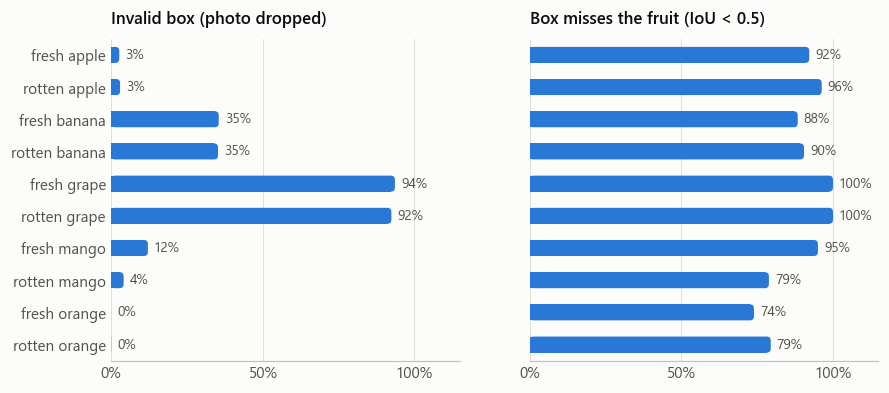

In [6]:
by_class = labels.groupby("cls").agg(invalid=("invalid", "mean"), miss=("iou", lambda s: (s < 0.5).mean()))
by_class = by_class.loc[list(names.values())] * 100
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
viz.hbars(axes[0], [n.replace("_", " ") for n in by_class.index], by_class.invalid.to_numpy(), fmt="{:.0f}%", xmax=115)
axes[0].set_title("Invalid box (photo dropped)")
viz.hbars(axes[1], [n.replace("_", " ") for n in by_class.index], by_class.miss.to_numpy(), fmt="{:.0f}%", xmax=115)
axes[1].set_title("Box misses the fruit (IoU < 0.5)")
for ax in axes:
    ax.set_xticks([0, 50, 100], ["0%", "50%", "100%"])
viz.render(fig)

Small fruit (grapes) and long, thin fruit (bananas) are hit hardest. Orange = stored box, blue = corrected box:

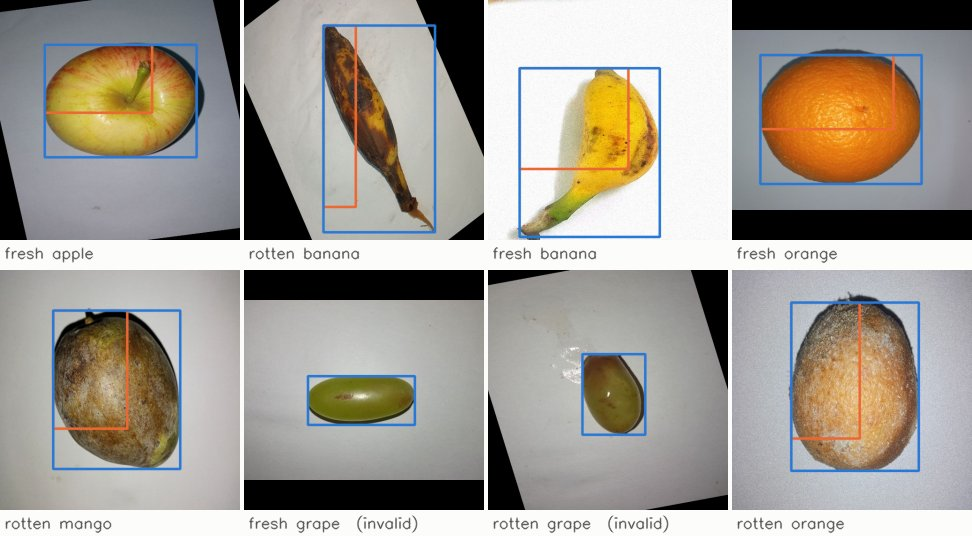

In [7]:
tiles, caps = [], []
for cls in ("fresh_apple", "rotten_banana", "fresh_banana", "fresh_orange", "rotten_mango", "fresh_grape", "rotten_grape", "rotten_orange"):
    i = labels[(labels.cls == cls) & (labels.iou < 0.5)].sample(1, random_state=1).index[0]
    img = cv2.imread(str(labels.image[i]))
    H, W = img.shape[:2]
    if not labels.invalid[i]:
        viz.draw_box(img, viz.yolo_to_xyxy(stored[i], W, H), viz.ORANGE)
    viz.draw_box(img, viz.yolo_to_xyxy(fixed[i], W, H), viz.BLUE)
    tiles.append(img)
    caps.append(cls.replace("_", " ") + ("  (invalid)" if labels.invalid[i] else ""))
viz.grid(tiles, caps, cols=4)

The stored numbers still contain the true corner and size, so the boxes can be rebuilt exactly without re-running the segmentation. `prepare_data.py --fix-boxes` does this with `fix_box`:

```python
x_min, width = xc - w / 2, xc + w / 2   # same for y
```

In [8]:
print(f"invalid boxes after the fix: {sum(not box_ok(*b) for b in fixed)} of {len(fixed):,}")

invalid boxes after the fix: 0 of 51,161


## Problem 2: copies across splits

The source photos already included augmented copies, and the split was random, so copies of the same photo ended up in different splits. A 256-bit difference hash finds resized and re-encoded copies (not flips or crops, so this undercounts):

In [9]:
hashes = {s: [dhash(f) for f in files] for s, files in images.items()}
md5 = {s: [hashlib.md5(f.read_bytes()).hexdigest() for f in files] for s, files in images.items()}
train_hashes, train_md5 = set(hashes["train"]), set(md5["train"])
for s in ("val", "test"):
    copies = sum(h in train_hashes for h in hashes[s])
    exact = sum(m in train_md5 for m in md5[s])
    print(f"{s}: {copies:,} of {len(images[s]):,} photos also appear in train ({exact:,} byte-for-byte identical)")

val: 1,055 of 5,116 photos also appear in train (962 byte-for-byte identical)
test: 970 of 5,117 photos also appear in train (881 byte-for-byte identical)


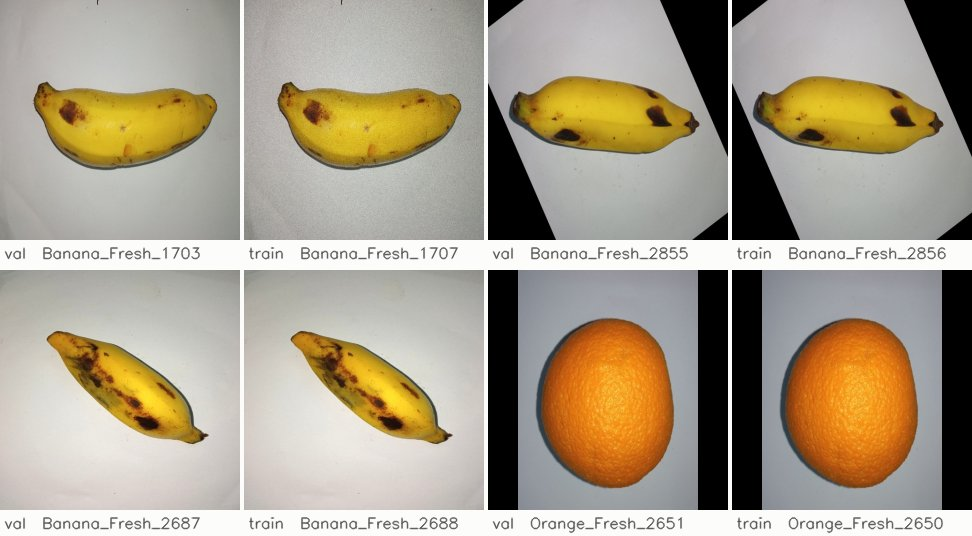

In [10]:
first_seen = {h: f for f, h in zip(images["train"], hashes["train"])}
pairs = [(v, first_seen[h]) for v, h in zip(images["val"], hashes["val"]) if h in first_seen]
random.seed(2)
tiles, caps = [], []
for v, t in random.sample(pairs, 4):
    tiles += [cv2.imread(str(v)), cv2.imread(str(t))]
    caps += [f"val  {v.stem}", f"train  {t.stem}"]
viz.grid(tiles, caps, cols=4)

In [11]:
is_copy = {f: h in train_hashes for f, h in zip(images["val"], hashes["val"])}
val = labels[labels.split == "val"].assign(copy=lambda d: d.image.map(is_copy))
leak = val.groupby("cls").agg(photos=("copy", "size"), copies=("copy", "sum")).loc[list(names.values())]
leak["share"] = (leak.copies / leak.photos).map("{:.0%}".format)
leak

,photos,copies,share
cls,,,
fresh_apple,583,112,19%
rotten_apple,38,0,0%
fresh_banana,614,339,55%
rotten_banana,505,75,15%
fresh_grape,612,20,3%
rotten_grape,515,10,2%
fresh_mango,604,99,16%
rotten_mango,506,35,7%
fresh_orange,621,331,53%


More than half of the fresh banana and fresh orange validation photos are copies of training photos. A score measured on them partly measures memory, so `prepare_data.py` leaves them out of the validation and test lists.

## The model trained on the fixed data

Fresh and rotten apple, banana and orange with corrected boxes, copies left out of validation and test:

```
python prepare_data.py --src datasets/studio --classes 6 --fix-boxes --out datasets/studio-6class
python train.py --data datasets/studio-6class/data_clean.yaml --batch 16 --name studio-6class
```

In [12]:
if not Path("datasets/studio-6class/data_clean.yaml").exists():
    subprocess.run([sys.executable, "prepare_data.py", "--src", str(SRC), "--classes", "6", "--fix-boxes",
                    "--out", "datasets/studio-6class"], check=True)
s6_splits, s6_names = load_dataset("datasets/studio-6class/data_clean.yaml")
s6 = {s: count_split(list_images(p), s6_names) for s, p in s6_splits.items()}
table = pd.DataFrame({s: v["per_class"] for s, v in s6.items()})
table.loc["total"] = table.sum()
table

,train,val,test
rotten_apple,304,38,35
rotten_banana,4051,430,434
rotten_orange,4206,484,494
fresh_apple,4931,471,514
fresh_banana,4793,275,267
fresh_orange,4793,290,291
total,23078,1988,2035


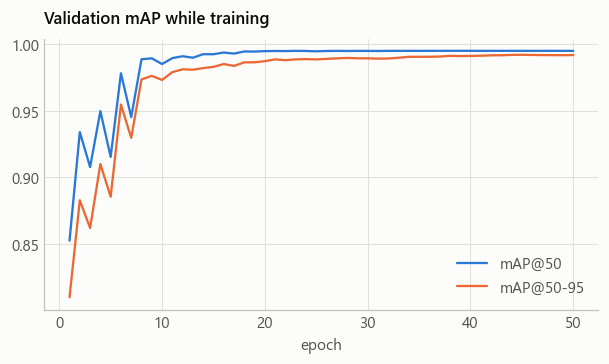

In [13]:
log = pd.read_csv("results/training_studio-6class.csv")
log.columns = log.columns.str.strip()
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(log.epoch, log["metrics/mAP50(B)"], color=viz.BLUE, label="mAP@50")
ax.plot(log.epoch, log["metrics/mAP50-95(B)"], color=viz.ORANGE, label="mAP@50-95")
ax.set(title="Validation mAP while training", xlabel="epoch")
ax.legend(loc="lower right")
viz.render(fig)

On its own test split it looks nearly perfect. 0.995 is the highest mAP@50 Ultralytics reports, so at IoU 0.5 it finds essentially every fruit:

In [14]:
def result(model, data, split):
    r = json.loads(Path(f"results/eval_{model}_{data}_{split}.json").read_text())
    return {"photos": r["images"], "fruit": r["instances"], "precision": r["precision"], "recall": r["recall"],
            "mAP@50": r["mAP50"], "mAP@50-95": r["mAP50-95"]}


pd.DataFrame({"validation": result("studio-6class", "studio-6class-clean", "val"),
              "test": result("studio-6class", "studio-6class-clean", "test")}).T.round(3).astype({"photos": int, "fruit": int})

,photos,fruit,precision,recall,mAP@50,mAP@50-95
validation,1988,1988,0.998,0.998,0.995,0.992
test,2035,2035,0.993,0.998,0.995,0.991


## Why it isn't the demo model

Every photo in this dataset is one fruit on a plain background. Scored on the combined dataset's test split, which has several fruit per photo, clutter, faces and everyday scenes, the same model falls apart. The combined model is weaker on the studio photos than on its own test split, but it doesn't collapse:

In [15]:
pd.DataFrame({"studio test (2,035 photos)": {m: result(k, "studio-6class-clean", "test")["mAP@50"] for m, k in
                                             (("studio model", "studio-6class"), ("combined model", "fruit-6class"))},
              "combined test (593 photos)": {m: result(k, "combined", "test")["mAP@50"] for m, k in
                                                    (("studio model", "studio-6class"), ("combined model", "fruit-6class"))}}).round(3).rename_axis("mAP@50")

,"studio test (2,035 photos)",combined test (593 photos)
mAP@50,,
studio model,0.995,0.094
combined model,0.629,0.986


The same test photos from the combined dataset, combined model on top, studio model below:

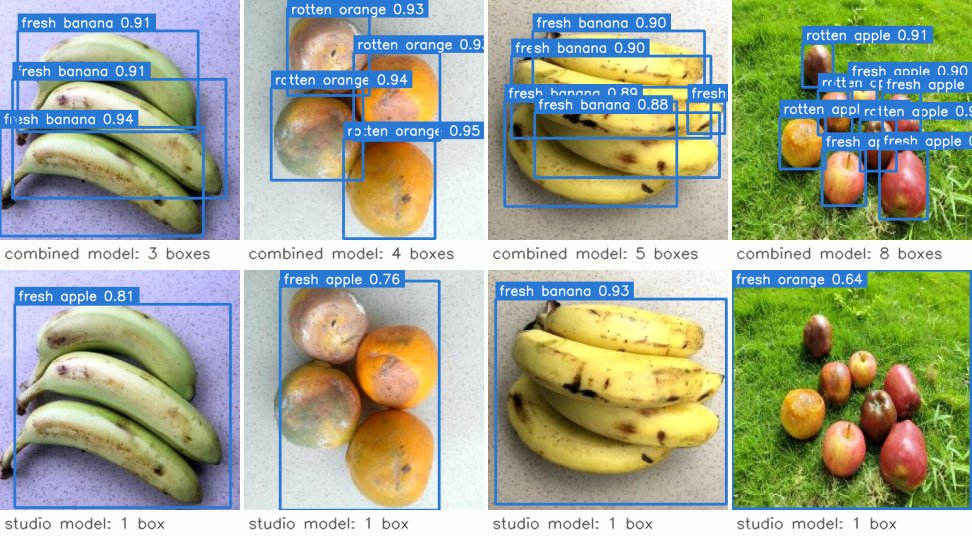

In [16]:
c_splits, c_names = load_dataset("datasets/combined/data.yaml")
random.seed(6)
crowded = [p for p in list_images(c_splits["test"])
           if len([l for l in (p.parent.parent / "labels" / f"{p.stem}.txt").read_text().splitlines() if l.strip()]) >= 3]
picks = random.sample(crowded, 4)
tiles, caps = [], []
for weights, label in (("models/fruit-6class.pt", "combined"),
                       ("models/studio-6class.pt", "studio")):
    for p, r in zip(picks, YOLO(weights).predict(picks, verbose=False)):
        img = cv2.imread(str(p))
        for (x1, y1, x2, y2), c, conf in zip(r.boxes.xyxy.tolist(), r.boxes.cls.int().tolist(), r.boxes.conf.tolist()):
            viz.draw_box(img, (x1, y1, x2, y2), viz.BLUE, f"{r.names[c].replace('_', ' ')} {conf:.2f}")
        tiles.append(img)
        caps.append(f"{label} model: {len(r.boxes)} box{'es' if len(r.boxes) != 1 else ''}")
viz.grid(tiles, caps, cols=4, tile=240)

A near-perfect score on a test split drawn from the same narrow source says little about the real world. The webcam demo uses the combined model.